# IDENTIFICADOR DE HABLANTES (Caracteristicas de Xi-Vector)

Etrena una red neuronal que aprende a identificar al hablante usando los Xi-vectors.

# Cargar dataset

personas = sorted([d for d in os.listdir(dataset_path) 
                   if os.path.isdir(os.path.join(dataset_path, d))])

Detecta automáticamente las clases (Hija, Hijo, Mamá).

# Segmentación

for i in range(0, len(audio_proc) - samples_segment + 1, step_segment):

 Divide el audio en ventanas de 2 segundos

 Salto de 0.5 segundos

Esto genera muchos ejemplos pequeño

# Filtro de energía

energia = np.mean(np.abs(seg))

if energia < energia_umbral:

continue



Elimina: silencio y ruido débil

# MFCC (igual que ESP32)

mfcc = calculoMFCC(seg)

 FFT
 Filtros Mel
 Log
 DCT

 Resultado:
 
Matriz de tamaño:
(20, 63)

# Generación de Xi-vector

features.append(np.mean(band_data))

features.append(np.std(band_data))

features.append(np.max(band_data))

features.append(np.min(band_data))


Por cada banda MFCC se calculan:

Media
Desviación estándar
Máximo
Mínimo

Se resumen los MFCC en estadísticas globales (media, variación, máximos y mínimos) para capturar la identidad del hablante, eliminando variaciones temporales irrelevantes como el contenido del mensaje

# Balanceo de datos

        if len(segs) > MAX_SEGMENTOS:
            segs = random.sample(segs, MAX_SEGMENTOS)

Evita desvalance extremo entre clases

# Normalización
        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(X)

 Convierte datos a:

media = 0
desviación = 1

# Archivos generados:

X_xvector.npy → datos

y_labels.npy → etiquetas

xvector_mean.npy → media

xvector_std.npy → std

# Process

In [ ]:
import os
import numpy as np
import soundfile as sf
from scipy.fftpack import dct
import random
import sys

# ==============================
# LOGGER
# ==============================

class Logger:
    def __init__(self, filename="procesamiento_log.txt"):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding="utf-8")
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
        self.log.flush()
    def flush(self):
        pass

sys.stdout = Logger()

# ==============================
# CONFIG
# ==============================

dataset_path = "../dataset_fam"
# NO cargamos ruido

sampling_rate = 16000
segment_duration = 2
samples_segment = sampling_rate * segment_duration
step_segment = samples_segment // 4  # 0.5s salto

Mel_bands = 20
Size_win = 512
Size_off = 256
frec_min = 20
frec_max = sampling_rate // 2

energia_umbral = 0.0025
MAX_SEGMENTOS = 700
TARGET_RMS = 0.065

# ==============================
# PREPROCESAMIENTO - EXACTAMENTE IGUAL QUE ESP32 v3.3
# ==============================

def audio_normalized_esp32(raw_signal):
    """
    EXACTAMENTE el mismo preprocesamiento que el ESP32 v3.3 / grabador v10.1.
    
    El grabador hace:
        int32_t raw = i2s_buffer[i] & 0xFFFFFF00;
        float current_raw = (float)(raw >> 14);
        float filtered = 0.995f * (last_filtered + current_raw - last_raw);
        int16_t val = (int16_t)(filtered * 2.0f);
    
    El ESP32 identificador hace:
        normalized_signal[j] = (filtered * 2.0f) / 32768.0f;
    """
    BUFLEN = len(raw_signal)
    normalized_signal = np.zeros(BUFLEN, dtype=np.float32)
    
    last_filtered = 0.0
    last_raw = 0.0
    
    for j in range(BUFLEN):
        # EXACTAMENTE igual que el grabador/ESP32
        raw = int(raw_signal[j]) & 0xFFFFFF00
        current_raw = float(raw >> 14)
        
        # Filtro paso alto identico
        filtered = 0.995 * (last_filtered + current_raw - last_raw)
        last_raw = current_raw
        last_filtered = filtered
        
        # Escalar a [-1, 1] igual que el ESP32
        normalized_signal[j] = (filtered * 2.0) / 32768.0
        
        # Clip de seguridad
        normalized_signal[j] = max(-1.0, min(1.0, normalized_signal[j]))
    
    return normalized_signal

def normalizar_volumen(audio, target_rms=TARGET_RMS):
    current_rms = np.sqrt(np.mean(audio**2))
    if current_rms > 0:
        audio = audio * (target_rms / current_rms)
    return np.clip(audio, -1.0, 1.0)

# ==============================
# MFCC (sin librosa) - IGUAL QUE MFCC.cpp
# ==============================

def calculoMFCC(audio):
    frames = []
    for i in range(0, len(audio) - Size_win, Size_off):
        frames.append(audio[i:i+Size_win])
    
    frames = np.array(frames, dtype=np.float32)
    hamming = np.hamming(Size_win)
    frames = frames * hamming
    
    fft = np.fft.rfft(frames, Size_win)
    power = np.abs(fft) ** 2  # Igual que MFCC.cpp: (r*r + im*im)
    
    # Filtros triangulares Mel
    mel_min = 2595 * np.log10(1 + frec_min / 700)
    mel_max = 2595 * np.log10(1 + frec_max / 700)
    mel_points = np.linspace(mel_min, mel_max, Mel_bands + 2)
    hz = 700 * (10 ** (mel_points / 2595) - 1)
    bins = np.floor((Size_win + 1) * hz / sampling_rate).astype(int)
    
    fbank = np.zeros((Mel_bands, int(Size_win / 2 + 1)), dtype=np.float32)
    for m in range(1, Mel_bands + 1):
        f1, f2, f3 = bins[m-1], bins[m], bins[m+1]
        for k in range(f1, f2):
            fbank[m-1, k] = (k - f1) / (f2 - f1 + 1e-9)
        for k in range(f2, f3):
            fbank[m-1, k] = (f3 - k) / (f3 - f2 + 1e-9)
    
    mel = np.dot(power, fbank.T)
    mel = np.where(mel == 0, np.finfo(float).eps, mel)
    log_mel = np.log(mel)  # Igual que MFCC.cpp
    mfcc = dct(log_mel, type=2, axis=1, norm='ortho')
    mfcc = mfcc.T  # Shape: (Mel_bands, num_frames)
    
    # Centrar a 63 ventanas (igual que MFCC.cpp)
    if mfcc.shape[1] >= 63:
        start = (mfcc.shape[1] - 63) // 2
        mfcc = mfcc[:, start:start+63]
    else:
        pad = 63 - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0, 0), (pad//2, pad - pad//2)), mode='constant')
    
    return mfcc

# ==============================
# Xi-VECTOR FEATURES
# ==============================

def extract_xvector_features(mfcc):
    features = []
    for band in range(Mel_bands):
        band_data = mfcc[band, :]
        features.append(np.mean(band_data))
        features.append(np.std(band_data))
        features.append(np.max(band_data))
        features.append(np.min(band_data))
    
    return np.array(features, dtype=np.float32)

# ==============================
# PROCESAR DATASET (SIN RUIDO)
# ==============================

personas = sorted([d for d in os.listdir(dataset_path) 
                   if os.path.isdir(os.path.join(dataset_path, d))])
print("Clases encontradas:", personas)

X = []
y = []

for label, persona in enumerate(personas):
    print(f"\n{'='*50}")
    print(f"PROCESANDO: {persona} (clase {label})")
    print(f"{'='*50}")
    
    persona_path = os.path.join(dataset_path, persona)
    archivos = [f for f in os.listdir(persona_path) if f.endswith(".wav")]
    print(f"  Archivos encontrados: {len(archivos)}")
    
    segs = []
    
    for archivo in archivos:
        print(f"  -> {archivo}")
        try:
            audio, sr = sf.read(os.path.join(persona_path, archivo), dtype='float32')
            if len(audio.shape) > 1:
                audio = np.mean(audio, axis=1)
            if sr != sampling_rate:
                from scipy.signal import resample
                audio = resample(audio, int(len(audio) * sampling_rate / sr))
            
            # Convertir a int32 como viene del ESP32
            audio_int32 = (audio * 32768).astype(np.int32)

            # ============================================
            # MISMO PREPROCESAMIENTO DEL ESP32
            # ============================================

            audio_proc = audio_normalized_esp32(audio_int32)

            # Normalizar volumen opcional
            # audio_proc = normalizar_volumen(audio_proc)
            
            n_segs = 0
            for i in range(0, len(audio_proc) - samples_segment + 1, step_segment):
                seg = audio_proc[i:i + samples_segment]
                energia = np.mean(np.abs(seg))
                if energia < energia_umbral:
                    continue
                
                # SIN DATA AUGMENTATION DE RUIDO
                
                mfcc = calculoMFCC(seg)
                if mfcc.shape == (Mel_bands, 63):
                    xvec_features = extract_xvector_features(mfcc)
                    segs.append(xvec_features)
                    n_segs += 1
            
            print(f"    Segmentos extraidos: {n_segs}")
        except Exception as e:
            print(f"    [ERROR] {archivo}: {e}")
    
    print(f"  Total segmentos antes de balancear: {len(segs)}")
    
    if len(segs) > MAX_SEGMENTOS:
        print(f"  -> Limitando a {MAX_SEGMENTOS} segmentos")
        segs = random.sample(segs, MAX_SEGMENTOS)
    
    print(f"  Segmentos finales: {len(segs)}")
    
    for feat in segs:
        X.append(feat)
        y.append(label)

# ==============================
# NORMALIZAR Y GUARDAR
# ==============================

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\n{'='*50}")
print("DATASET FINAL (SIN RUIDO)")
print(f"{'='*50}")
print(f"Forma X: {X.shape}")
print(f"Forma y: {y.shape}")
print(f"Clases: {personas}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mean = scaler.mean_
std = scaler.scale_

print(f"\nEstadisticas (por feature):")
print(f"  Mean range: [{np.min(mean):.4f}, {np.max(mean):.4f}]")
print(f"  Std range:  [{np.min(std):.4f}, {np.max(std):.4f}]")

np.save("X_xvector.npy", X_scaled)
np.save("y_labels.npy", y)
np.save("labels.npy", personas)
np.save("xvector_mean.npy", mean)
np.save("xvector_std.npy", std)

with open("normalizacion_params.txt", "w") as f:
    f.write("// Xi-Vector normalization params\n")
    f.write(f"const int XVEC_DIM = {len(mean)};\n")
    f.write("const float XVEC_MEAN[] = {")
    f.write(", ".join([f"{m:.8f}f" for m in mean]))
    f.write("};\n")
    f.write("const float XVEC_STD[] = {")
    f.write(", ".join([f"{s:.8f}f" for s in std]))
    f.write("};\n")

from collections import Counter
print("\nDistribucion final:")
for label, count in sorted(Counter(y).items()):
    print(f"  {personas[label]}: {count}")

print("\nArchivos guardados:")
print("   - X_xvector.npy")
print("   - y_labels.npy")
print("   - labels.npy")
print("   - xvector_mean.npy")
print("   - xvector_std.npy")
print("   - normalizacion_params.txt")

Clases encontradas: ['hija', 'hijo', 'mama', 'papa']

PROCESANDO: hija (clase 0)
  Archivos encontrados: 5
  -> hija_1_gustos.wav
    Segmentos extraidos: 37
  -> hija_1_molestia.wav
    Segmentos extraidos: 37
  -> hija_1_rutina.wav
    Segmentos extraidos: 37
  -> hija_1_saludo.wav
    Segmentos extraidos: 37
  -> hija_1_vacaciones.wav
    Segmentos extraidos: 37
  Total segmentos antes de balancear: 185
  Segmentos finales: 185

PROCESANDO: hijo (clase 1)
  Archivos encontrados: 5
  -> hijo_1_gustos.wav
    Segmentos extraidos: 37
  -> hijo_1_molestia.wav
    Segmentos extraidos: 37
  -> hijo_1_rutina.wav
    Segmentos extraidos: 37
  -> hijo_1_saludo.wav
    Segmentos extraidos: 36
  -> hijo_1_vacaciones.wav
    Segmentos extraidos: 36
  Total segmentos antes de balancear: 183
  Segmentos finales: 183

PROCESANDO: mama (clase 2)
  Archivos encontrados: 5
  -> mama_gustos.wav
    Segmentos extraidos: 37
  -> mama_molestia.wav
    Segmentos extraidos: 37
  -> mama_rutina.wav
    Segm


Estadisticas (por feature):
  Mean range: [-30.0206, 16.6891]
  Std range:  [0.0849, 6.1258]

Distribucion final:
  hija: 185
  hijo: 183
  mama: 185
  papa: 184

Archivos guardados:
   - X_xvector.npy
   - y_labels.npy
   - labels.npy
   - xvector_mean.npy
   - xvector_std.npy
   - normalizacion_params.txt
Dataset: (737, 80), Clases: ['hija' 'hijo' 'mama' 'papa']
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 80)]              0         
                                                                 
 dense (Dense)               (None, 128)               10368     
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)     

-------------------------

-----------------------

# Entrenamietno

1. Cargar datos

X = np.load("X_xvector.npy")

y = np.load("y_labels.npy")

---------------------------------

2. División de datos

        train_test_split(..., test_size=0.2)

 80% entrenamiento
 
 20% validación

------------------

Balanceo automático

        class_weights = compute_class_weight(...)

Evita sesgo si una clase tiene más datos

----------------------

# Modelo (Mini Xi-vector)

        Dense(128) → BatchNorm → Dropout

        Dense(64)  → BatchNorm → Dropout

        Dense(32)

        Dense(output)
        

 Explicación:

Dense → aprende patrones

 BatchNorm → estabiliza entrenamiento

 Dropout → evita overfitting


 Capa importante:

name="xvector_embedding"

 Representa la identidad del hablante

-----------------

# Compilación

loss='sparse_categorical_crossentropy'

optimizer=Adam

Softmax → probabilidades por clase

# Evaluacioon

classification_report(...)

confusion_matrix(...)

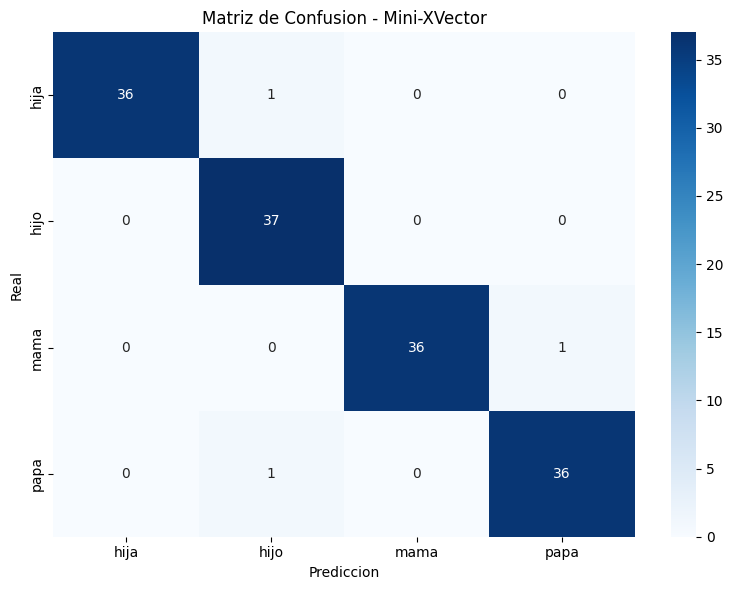

INFO:tensorflow:Assets written to: C:\Users\EALO4\AppData\Local\Temp\tmp7_rwfifi\assets
INFO:tensorflow:Assets written to: C:\Users\EALO4\AppData\Local\Temp\tmpvt0v2szx\assets
c:\Users\EALO4\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\lite\python\convert.py:789: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


In [2]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# CARGAR DATOS
# ==============================

X = np.load("X_xvector.npy")
y = np.load("y_labels.npy")
labels = np.load("labels.npy", allow_pickle=True)

print(f"Dataset: {X.shape}, Clases: {labels}")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# ==============================
# MODELO MINI-XVECTOR
# ==============================

def crear_modelo_xvector(num_classes, input_dim=80):
    inputs = tf.keras.Input(shape=(input_dim,))
    
    x = tf.keras.layers.Dense(128, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(64, activation='relu', name="xvector_embedding")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = crear_modelo_xvector(len(labels))
model.summary()

total_params = model.count_params()
print(f"\n{'='*50}")
print(f"TOTAL PARAMETROS: {total_params:,}")
print(f"Tamaño estimado FP32: {total_params * 4 / 1024:.1f} KB")
print(f"Tamaño estimado INT8: {total_params * 1 / 1024:.1f} KB")
print(f"{'='*50}")

# ==============================
# ENTRENAR
# ==============================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# ==============================
# EVALUAR
# ==============================

val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"\n{'='*50}")
print(f"VALIDATION ACCURACY: {val_acc:.4f}")
print(f"{'='*50}")

y_pred = np.argmax(model.predict(X_val), axis=1)

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=labels))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusion - Mini-XVector')
plt.ylabel('Real')
plt.xlabel('Prediccion')
plt.tight_layout()
plt.savefig('confusion_matrix_xvector.png', dpi=150)
plt.show()

# ==============================
# GUARDAR Y EXPORTAR
# ==============================

model.save("xvector_model.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_float = converter.convert()

with open("xvector_model.tflite", "wb") as f:
    f.write(tflite_float)

print(f"\nTamaño TFLite (float): {len(tflite_float)/1024:.1f} KB")

def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

tflite_int8 = converter_int8.convert()

with open("xvector_model_int8.tflite", "wb") as f:
    f.write(tflite_int8)

print(f"Tamaño TFLite (INT8): {len(tflite_int8)/1024:.1f} KB")

def tflite_to_h(tflite_data, filename, varname):
    with open(filename, "w") as f:
        f.write(f"#ifndef {varname.upper()}_H\n")
        f.write(f"#define {varname.upper()}_H\n\n")
        f.write(f"const unsigned int {varname}_len = {len(tflite_data)};\n\n")
        f.write(f"const unsigned char {varname}[] = {{\n")
        
        for i in range(0, len(tflite_data), 12):
            line = tflite_data[i:i+12]
            f.write("    " + ", ".join(f"0x{b:02x}" for b in line) + ",\n")
        
        f.write("};\n\n")
        f.write(f"#endif\n")
    
    print(f"Generado: {filename} ({len(tflite_data)/1024:.1f} KB)")

tflite_to_h(tflite_int8, "modelo_hablante.h", "modelo_hablante_tflite")

print("\nArchivos generados:")
print("   - xvector_model.h5")
print("   - xvector_model.tflite")
print("   - xvector_model_int8.tflite")
print("   - modelo_hablante.h")
print("   - confusion_matrix_xvector.png")

# Muestras de audio

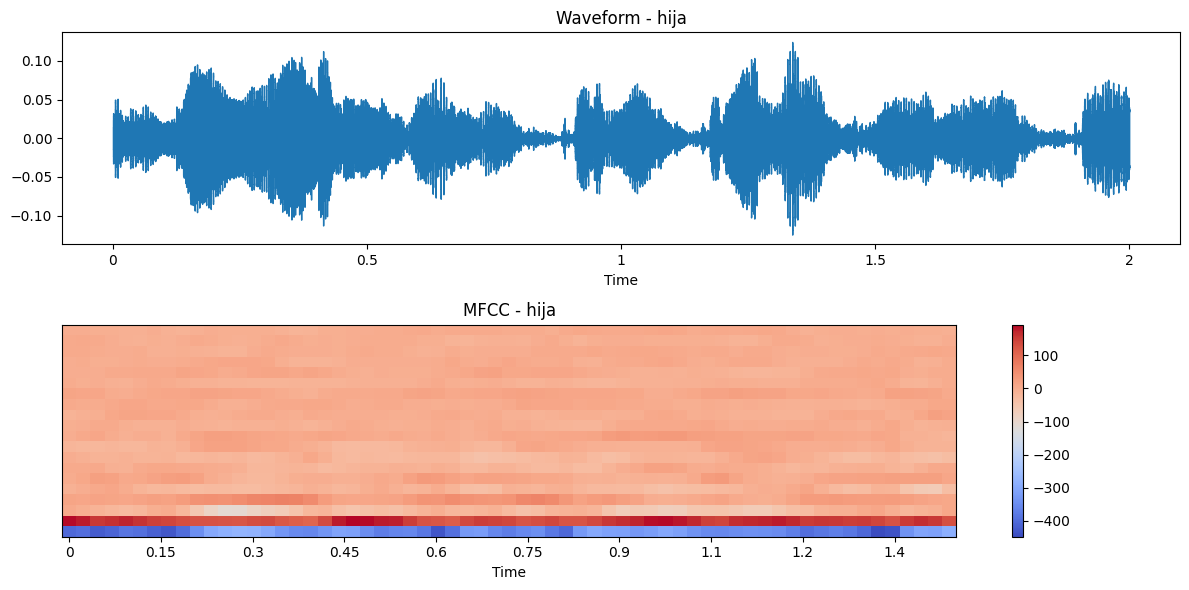

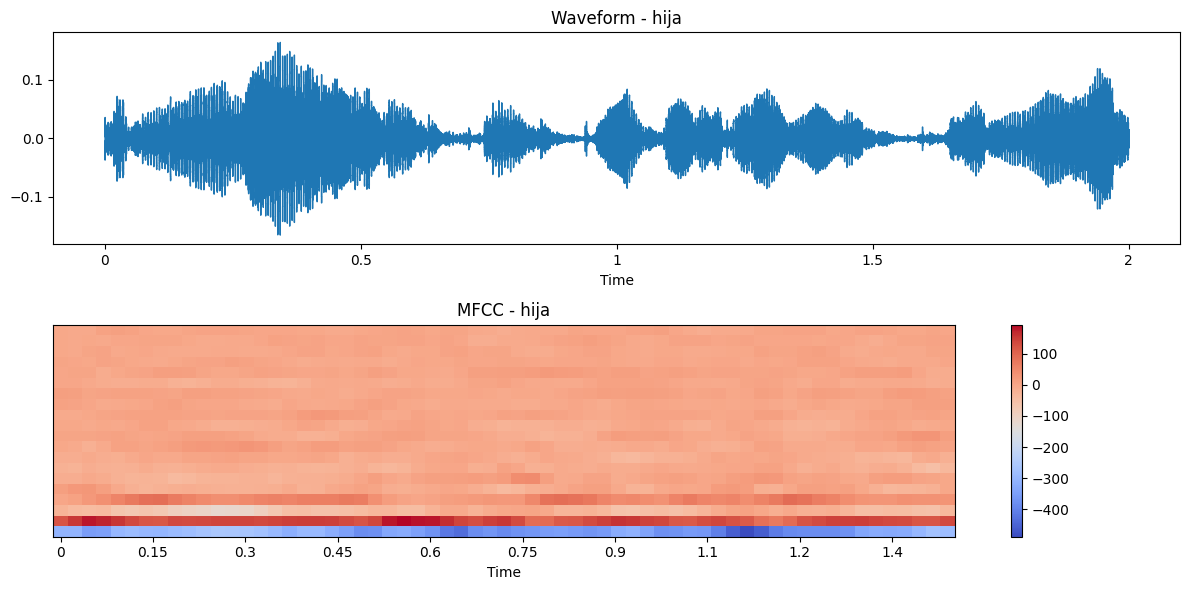

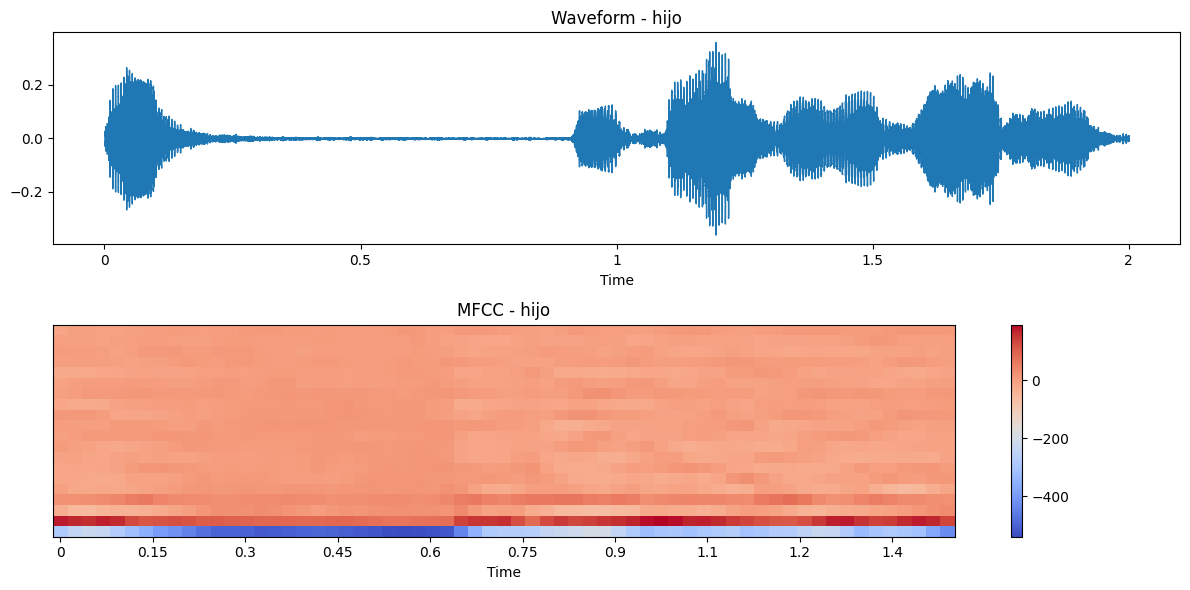

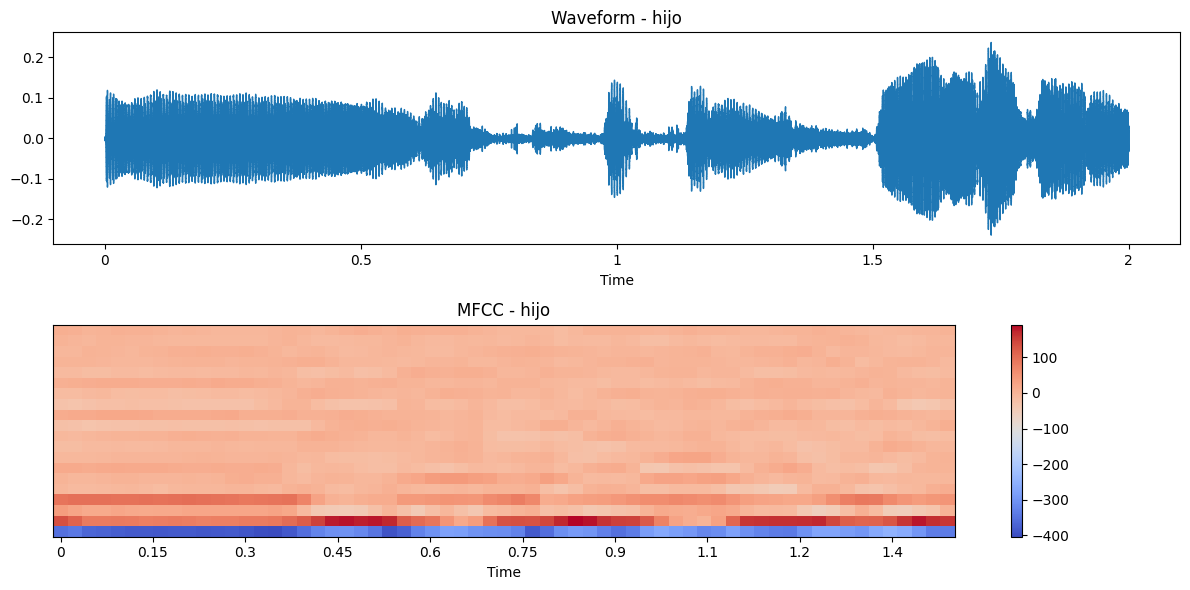

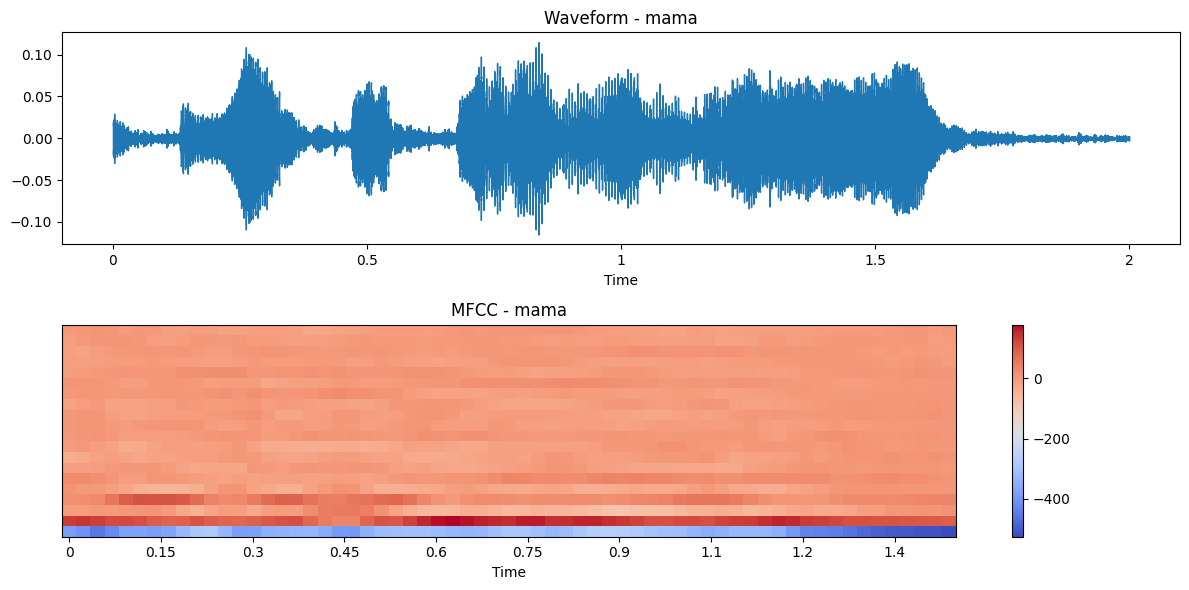

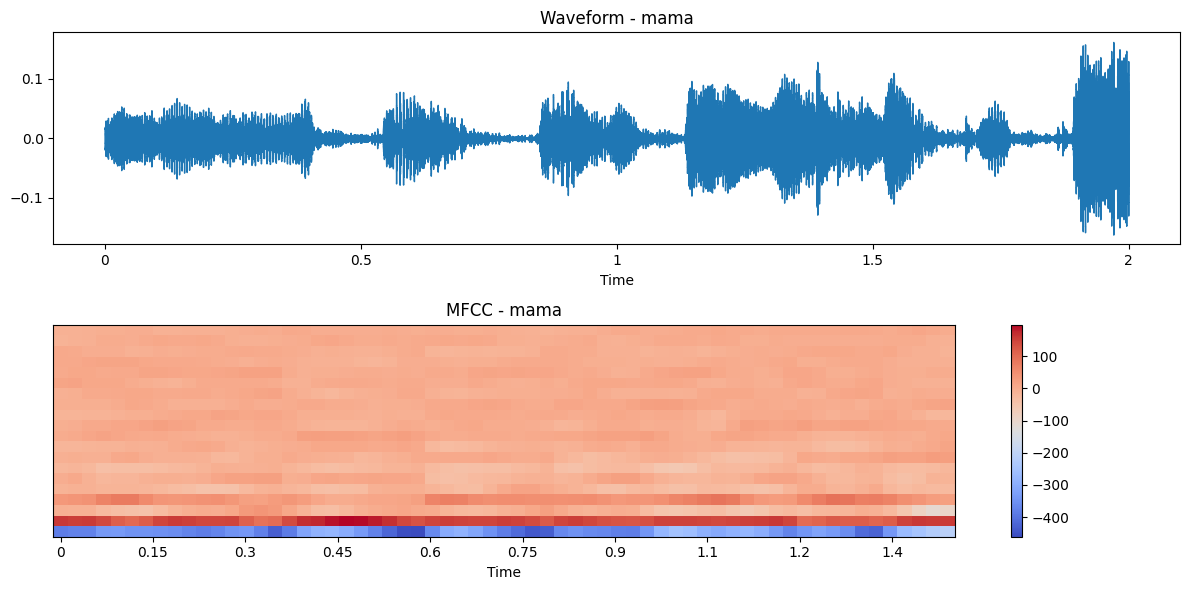

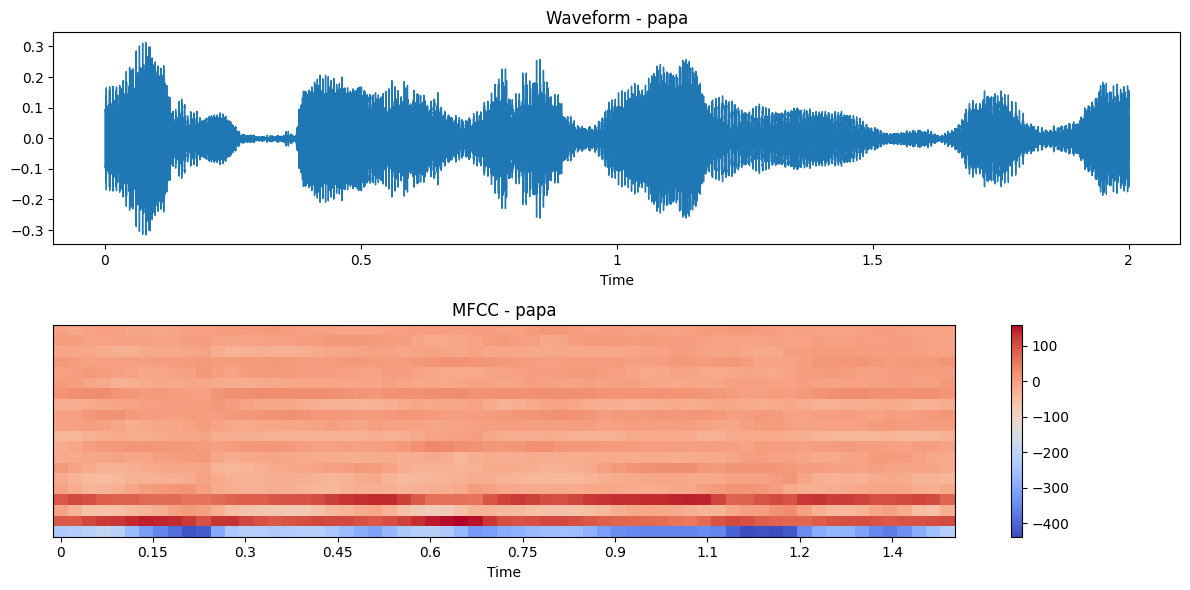

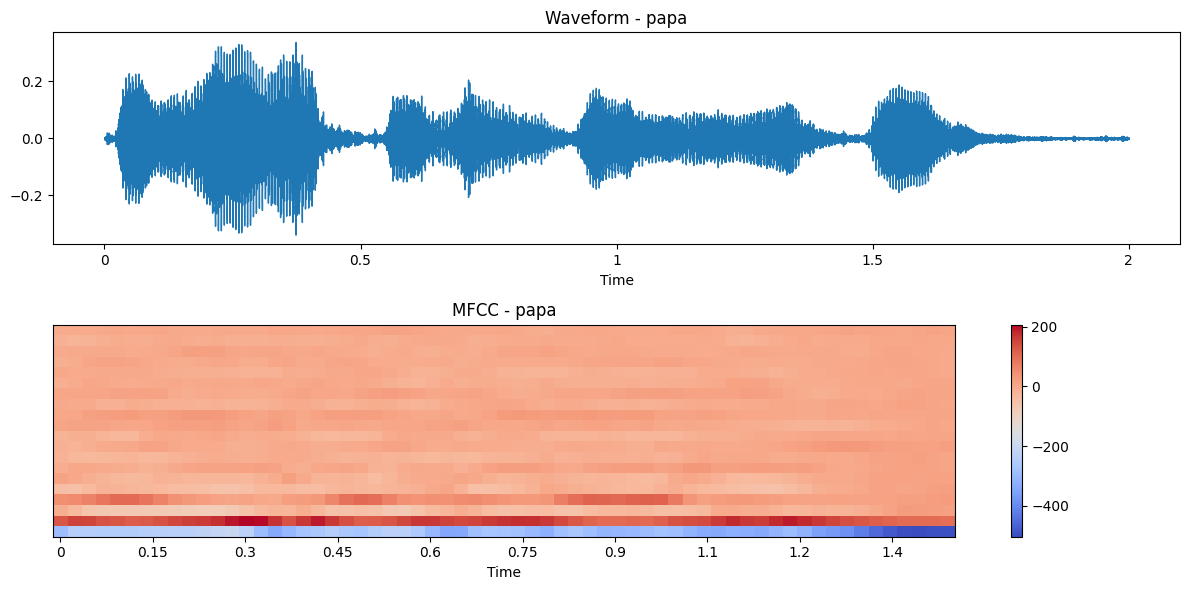

In [4]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CONFIG
# ============================================

DATASET_DIR = "../dataset_fam"   # cambia si tu carpeta tiene otro nombre
SR = 16000
SEGMENT_SECONDS = 2
SEGMENT_SAMPLES = SR * SEGMENT_SECONDS

# ============================================
# OBTENER CARPETAS
# ============================================

speaker_folders = [
    os.path.join(DATASET_DIR, d)
    for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
]

print("HABLANTES ENCONTRADOS:")
for s in speaker_folders:
    print("-", os.path.basename(s))

# ============================================
# VISUALIZAR
# ============================================

for speaker_path in speaker_folders:

    speaker_name = os.path.basename(speaker_path)

    wav_files = [
        os.path.join(speaker_path, f)
        for f in os.listdir(speaker_path)
        if f.endswith(".wav")
    ]

    if len(wav_files) == 0:
        continue

    # seleccionar máximo 2 audios
    selected_files = random.sample(
        wav_files,
        min(2, len(wav_files))
    )

    for idx, audio_path in enumerate(selected_files):

        print("\n===================================")
        print("HABLANTE:", speaker_name)
        print("AUDIO:", os.path.basename(audio_path))
        print("===================================")

        # cargar audio
        audio, sr = librosa.load(audio_path, sr=SR)

        # tomar solo 2 segundos
        if len(audio) > SEGMENT_SAMPLES:
            start = random.randint(0, len(audio) - SEGMENT_SAMPLES)
            audio = audio[start:start + SEGMENT_SAMPLES]

        # ============================================
        # MFCC
        # ============================================

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=20
        )

        # ============================================
        # FIGURA
        # ============================================

        fig, ax = plt.subplots(2, 1, figsize=(12, 6))

        # Waveform
        librosa.display.waveshow(audio, sr=sr, ax=ax[0])
        ax[0].set_title(f"Waveform - {speaker_name}")

        # MFCC
        img = librosa.display.specshow(
            mfcc,
            x_axis='time',
            ax=ax[1]
        )

        ax[1].set_title(f"MFCC - {speaker_name}")

        plt.colorbar(img, ax=ax[1])

        plt.tight_layout()
        plt.show()

----------------------------

In [ ]:
 [0:0.19] [1:0.45] [2:0.36] 
⏳ Analizando...
AVG: [0:0.19] [1:0.48] [2:0.33] 
⏳ Analizando...
AVG: [0:0.19] [1:0.49] [2:0.32] 
AVG: [0:0.02] [1:0.63] [2:0.35] 
AVG: [0:0.03] [1:0.67] [2:0.30] 
🎤 HABLANTE: Hijo (67.1%)
AVG: [0:0.05] [1:0.53] [2:0.42] 
🔇 No voz real
🔇 No voz real
🔇 No voz real
AVG: [0:0.05] [1:0.52] [2:0.43] 
⏳ Analizando...
AVG: [0:0.04] [1:0.58] [2:0.38] 
⏳ Analizando...
AVG: [0:0.03] [1:0.75] [2:0.22] 
🎤 HABLANTE: Hijo (75.3%)
AVG: [0:0.04] [1:0.80] [2:0.16] 
🎤 HABLANTE: Hijo (80.3%)
AVG: [0:0.05] [1:0.77] [2:0.18] 
🎤 HABLANTE: Hijo (77.2%)
AVG: [0:0.10] [1:0.64] [2:0.26] 
AVG: [0:0.10] [1:0.53] [2:0.37] 
🔇 No voz real
AVG: [0:0.11] [1:0.36] [2:0.54] 
⏳ Analizando...
AVG: [0:0.06] [1:0.32] [2:0.63] 
⏳ Analizando...
AVG: [0:0.12] [1:0.22] [2:0.65] 
🎤 HABLANTE: Mama (65.5%)
AVG: [0:0.13] [1:0.20] [2:0.67] 
🎤 HABLANTE: Mama (66.5%)
AVG: [0:0.13] [1:0.17] [2:0.70] 
🎤 HABLANTE: Mama (69.8%)
AVG: [0:0.18] [1:0.16] [2:0.67] 
🎤 HABLANTE: Mama (66.5%)
AVG: [0:0.21] [1:0.11] [2:0.68] 
🎤 HABLANTE: Mama (67.8%)
AVG: [0:0.24] [1:0.12] [2:0.64] 
AVG: [0:0.17] [1:0.15] [2:0.68] 
🎤 HABLANTE: Mama (68.2%)
AVG: [0:0.11] [1:0.33] [2:0.56] 
AVG: [0:0.07] [1:0.55] [2:0.38] 
⏳ Analizando...
AVG: [0:0.04] [1:0.69] [2:0.26] 
⏳ Analizando...
AVG: [0:0.11] [1:0.63] [2:0.26] 
AVG: [0:0.20] [1:0.45] [2:0.35] 
??? INSEGURO
AVG: [0:0.21] [1:0.43] [2:0.36] 
??? INSEGURO
AVG: [0:0.29] [1:0.42] [2:0.29] 
AVG: [0:0.36] [1:0.39] [2:0.25] 
??? INSEGURO
AVG: [0:0.59] [1:0.23] [2:0.17] 
⏳ Analizando...
AVG: [0:0.61] [1:0.15] [2:0.25] 
⏳ Analizando...
AVG: [0:0.48] [1:0.34] [2:0.19] 
AVG: [0:0.23] [1:0.52] [2:0.24] 
⏳ Analizando...
AVG: [0:0.15] [1:0.66] [2:0.20] 
⏳ Analizando...
AVG: [0:0.17] [1:0.64] [2:0.19] 
AVG: [0:0.18] [1:0.70] [2:0.13] 
🎤 HABLANTE: Hijo (69.8%)
AVG: [0:0.10] [1:0.80] [2:0.10] 
🎤 HABLANTE: Hijo (80.5%)
AVG: [0:0.07] [1:0.77] [2:0.17] 
🎤 HABLANTE: Hijo (77.0%)
AVG: [0:0.07] [1:0.67] [2:0.26] 
🎤 HABLANTE: Hijo (66.9%)
AVG: [0:0.08] [1:0.51] [2:0.41] 
??? INSEGURO
AVG: [0:0.05] [1:0.57] [2:0.37] 
AVG: [0:0.05] [1:0.48] [2:0.48] 
⏳ Analizando...

In [ ]:
🔇 No voz real
🔇 No voz real
🔇 No voz real
🔇 No voz real
AVG: [0:0.02] [1:0.50] [2:0.15] 
⏳ Analizando...
AVG: [0:0.02] [1:0.78] [2:0.20] 
⏳ Analizando...
AVG: [0:0.02] [1:0.84] [2:0.14] 
🎤 HABLANTE: Hijo (83.6%)
AVG: [0:0.03] [1:0.80] [2:0.16] 
🎤 HABLANTE: Hijo (80.5%)
AVG: [0:0.04] [1:0.77] [2:0.18] 
🎤 HABLANTE: Hijo (77.5%)
AVG: [0:0.04] [1:0.77] [2:0.19] 
🎤 HABLANTE: Hijo (77.5%)
AVG: [0:0.05] [1:0.67] [2:0.28] 
🎤 HABLANTE: Hijo (67.2%)
AVG: [0:0.07] [1:0.56] [2:0.36] 
AVG: [0:0.07] [1:0.43] [2:0.49] 
⏳ Analizando...
AVG: [0:0.06] [1:0.48] [2:0.46] 
⏳ Analizando...
AVG: [0:0.05] [1:0.43] [2:0.53] 
⏳ Analizando...
AVG: [0:0.05] [1:0.42] [2:0.54] 
⏳ Analizando...
AVG: [0:0.05] [1:0.43] [2:0.53] 
AVG: [0:0.07] [1:0.52] [2:0.41] 
⏳ Analizando...
AVG: [0:0.11] [1:0.54] [2:0.35] 
⏳ Analizando...
AVG: [0:0.14] [1:0.46] [2:0.40] 
??? INSEGURO
AVG: [0:0.11] [1:0.42] [2:0.47] 
⏳ Analizando...
AVG: [0:0.07] [1:0.47] [2:0.46] 
⏳ Analizando...
AVG: [0:0.11] [1:0.39] [2:0.49] 
⏳ Analizando...
AVG: [0:0.12] [1:0.44] [2:0.44] 
⏳ Analizando...
AVG: [0:0.27] [1:0.30] [2:0.43] 
⏳ Analizando...
AVG: [0:0.27] [1:0.32] [2:0.41] 
⏳ Analizando...
AVG: [0:0.29] [1:0.33] [2:0.39] 
??? INSEGURO
AVG: [0:0.28] [1:0.34] [2:0.38] 
??? INSEGURO
AVG: [0:0.21] [1:0.43] [2:0.36] 
⏳ Analizando...
AVG: [0:0.36] [1:0.30] [2:0.34] 
⏳ Analizando...
AVG: [0:0.21] [1:0.46] [2:0.32] 
⏳ Analizando...
AVG: [0:0.24] [1:0.36] [2:0.40] 
⏳ Analizando...
AVG: [0:0.05] [1:0.38] [2:0.56] 
⏳ Analizando...
AVG: [0:0.24] [1:0.20] [2:0.56] 
AVG: [0:0.22] [1:0.30] [2:0.48] 
AVG: [0:0.26] [1:0.29] [2:0.45] 
AVG: [0:0.15] [1:0.34] [2:0.51] 
AVG: [0:0.15] [1:0.23] [2:0.63] 
AVG: [0:0.16] [1:0.17] [2:0.67] 
🎤 HABLANTE: Mama (66.8%)
AVG: [0:0.11] [1:0.22] [2:0.67] 
🎤 HABLANTE: Mama (66.5%)
AVG: [0:0.22] [1:0.27] [2:0.51] 
AVG: [0:0.19] [1:0.36] [2:0.45] 
??? INSEGURO
AVG: [0:0.17] [1:0.43] [2:0.40] 
⏳ Analizando...
AVG: [0:0.05] [1:0.53] [2:0.42] 
⏳ Analizando...
AVG: [0:0.13] [1:0.47] [2:0.40] 
??? INSEGURO
AVG: [0:0.16] [1:0.38] [2:0.46] 
⏳ Analizando...
AVG: [0:0.25] [1:0.28] [2:0.47] 
⏳ Analizando...
AVG: [0:0.18] [1:0.29] [2:0.52] 
AVG: [0:0.16] [1:0.31] [2:0.53] 
AVG: [0:0.06] [1:0.24] [2:0.70] 
🎤 HABLANTE: Mama (69.7%)
AVG: [0:0.03] [1:0.27] [2:0.70] 
🎤 HABLANTE: Mama (70.4%)
AVG: [0:0.03] [1:0.26] [2:0.72] 
🎤 HABLANTE: Mama (71.6%)
AVG: [0:0.05] [1:0.28] [2:0.67] 
🎤 HABLANTE: Mama (67.2%)
AVG: [0:0.07] [1:0.23] [2:0.70] 
🎤 HABLANTE: Mama (70.3%)
AVG: [0:0.18] [1:0.14] [2:0.68] 
🎤 HABLANTE: Mama (68.0%)
AVG: [0:0.18] [1:0.25] [2:0.58] 
AVG: [0:0.20] [1:0.31] [2:0.49] 
AVG: [0:0.16] [1:0.35] [2:0.50] 
AVG: [0:0.32] [1:0.22] [2:0.46] 
AVG: [0:0.35] [1:0.16] [2:0.49] 
AVG: [0:0.35] [1:0.20] [2:0.46] 
AVG: [0:0.20] [1:0.26] [2:0.54] 